# RMBI3110 — Assignment 2: The Alpha Challenge
## Can You Beat the Market with Machine Learning?

**Professor Xuhu Wan | HKUST Business School | Spring 2026**

**Names & Student IDs:** *(fill in)*

---

**Dataset:** `alpha_dataset_v2.csv` (provided via Google Drive)

| Category | Examples | Count |
|---|---|---|
| Price / Momentum | `ret_1`, `ret_2_12`, `vol_12m`, `beta`, `ivol` | 12 |
| Accounting / Value | `bm`, `ep`, `gpa`, `roe`, `ag`, `lev` | 15 |
| Analyst | `sue`, `revision`, `dispersion`, `beat` | 6 |
| Technical | `rsi_14`, `macd_hist`, `bb_position`, `roc_3` | 13 |
| Options | `iv_atm_30d`, `iv_skew`, `pc_vol_ratio`, `vrp` | 6 |
| Peer / Industry | `peer_sue`, `leader_ret`, `ind_mom` | 17 |
| Quarterly fundamentals | `sue_q`, `rev_surp`, `earn_growth_yoy` | 19 |
| Interactions | `mom_x_size`, `val_x_prof`, `mom_x_vol` | 10 |
| Sector / Macro | `sector_ret_avg`, `macro_unc_1m` | 13 |
| **Total raw features** | | **116** |

**Key columns:**

- `y_xs`: standardized forward monthly return  (training target)
- `y_raw`: raw forward monthly return (portfolio evaluation only)


---
## 1. Setup

Load the dataset, define constants, and create helper functions for performance evaluation and plotting.

In [24]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LassoCV
from sklearn.base import clone
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({'figure.figsize': (13, 5.5), 'font.size': 11})

# ── Load data ──
LOCAL_DATA = "../Data/alpha_dataset_v2.csv"
df = pd.read_csv(LOCAL_DATA)
print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} cols, {df['ym'].nunique()} months")

# ── Constants ──
TRAIN_TARGET = 'y_xs'   # Cross-sectionally standardized — better for learning relative patterns
EVAL_TARGET = 'y_raw'   # Actual returns — what the portfolio earns
OOS_START = '2005-01'
K = 10                   # Concentrated portfolio: top 10 picks maximize alpha per stock

df_sp = df.copy()
print(f"Universe: {df_sp['permno'].nunique()} stocks")

# ── SPY benchmark ──
ff = df_sp.groupby('ym')[['Mkt_RF', 'rf_ff']].first().sort_index()
ff['spy_ret'] = ff['Mkt_RF'] + ff['rf_ff']
spy_oos = ff.loc[ff.index >= OOS_START, 'spy_ret']
spy_cum = (1 + spy_oos).cumprod()
spy_sr = spy_oos.mean() / spy_oos.std() * np.sqrt(12)
print(f"SPY OOS: {len(spy_oos)} months, SR = {spy_sr:.2f}")

Dataset: 257,800 rows, 229 cols, 407 months
Universe: 1216 stocks
SPY OOS: 227 months, SR = 0.66


In [25]:
def perf(s, name=''):
    """Compute annualized performance metrics for a monthly return series."""
    mu = s.mean() * 12
    vol = s.std() * np.sqrt(12)
    sr = mu / vol if vol > 0 else 0
    cum = (1 + s).cumprod()
    mdd = (cum / cum.cummax() - 1).min()
    return {'Strategy': name, 'SR': round(sr, 2), 'Ann Mean': f'{mu:.1%}',
            'Ann Vol': f'{vol:.1%}', 'MDD': f'{mdd:.1%}',
            'Total': f'{cum.iloc[-1]-1:.0%}'}


def plot_strats(strat_dict, title):
    """Plot cumulative wealth for multiple strategies against SPY benchmark."""
    fig, ax = plt.subplots(figsize=(13, 5.5))
    for name, s in strat_dict.items():
        cum = (1 + s).cumprod()
        sr = s.mean() / s.std() * np.sqrt(12) if s.std() > 0 else 0
        ax.plot(cum.index, cum.values, label=f'{name} (SR={sr:.2f})', linewidth=1.3)
    ax.plot(spy_cum.index, spy_cum.values, color='gray', linestyle='--',
            linewidth=2.2, label=f'SPY (SR={spy_sr:.2f})', alpha=0.8)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Cumulative Wealth ($1)')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(alpha=0.3)
    ticks = list(range(0, len(ax.get_xticks()), max(1, len(ax.get_xticks()) // 15)))
    ax.set_xticks([ax.get_xticks()[i] for i in ticks if i < len(ax.get_xticks())])
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()

print("Helper functions loaded.")

Helper functions loaded.


---
## 2. Feature Engineering

We build two feature tiers from the cross-sectionally standardized (`_xs`) columns:

- **Tier 1 (~52 features):** Core factors + hand-crafted composites for Lasso. Designed for interpretability.
- **Tier 2 (~118 features):** All `_xs` columns + engineered features for HGB. Gives the tree model maximum information.

Engineered features include economically motivated interactions (e.g., momentum in quality firms), composite signals (averaging related measures to reduce noise), and non-linear transforms (squared terms for Lasso). All composites average only columns that actually exist to avoid signal dilution.

In [26]:
# ── Feature Engineering ──────────────────────────────────────────────

def _get_existing(df_slice, cols):
    """Return DataFrame of only the columns that actually exist. No zero-padding."""
    return df_slice[[c for c in cols if c in df_slice.columns]]


def _build_engineered_features(df_slice):
    """Build all engineered features (shared by both tiers)."""
    feat = pd.DataFrame(index=df_slice.index)

    # Helper: get column or zeros (for individual features, not composites)
    def _s(col):
        return df_slice[col] if col in df_slice.columns else pd.Series(0.0, index=df_slice.index)

    # ── 1. Interaction terms ─────────────────────────────────────
    # Momentum × Quality: momentum more reliable in quality firms
    feat['mom_x_quality'] = _s('ret_2_12_xs') * _s('gpa_xs')
    feat['mom_x_roe'] = _s('ret_2_12_xs') * _s('roe_xs')

    # Value × Low-volatility: value stronger in stable firms
    feat['val_x_lowvol'] = _s('bm_xs') * (-_s('vol_12m_xs'))
    feat['ep_x_lowvol'] = _s('ep_xs') * (-_s('vol_12m_xs'))

    # Earnings surprise × Analyst signals
    feat['sue_x_lowdisp'] = _s('sue_xs') * (-_s('dispersion_xs'))
    feat['sue_x_revision'] = _s('sue_xs') * _s('revision_xs')

    # Momentum × Low idiosyncratic vol
    feat['mom_x_lowivol'] = _s('ret_2_12_xs') * (-_s('ivol_xs'))

    # Value × Profitability: cheap + profitable = classic quality-value
    feat['bm_x_roe'] = _s('bm_xs') * _s('roe_xs')
    feat['ep_x_gpa'] = _s('ep_xs') * _s('gpa_xs')

    # ── 2. Non-linear transforms (for Lasso — HGB can learn these but they don't hurt)
    for col in ['ret_2_12_xs', 'ret_1_xs', 'sue_xs', 'bm_xs', 'revision_xs']:
        raw = _s(col)
        feat[f'{col}_sq'] = raw ** 2 * np.sign(raw)

    # ── 3. Composite signals (average only existing columns) ─────
    earn_cols = ['sue_xs', 'sue_q_xs', 'rev_surp_xs', 'earn_growth_yoy_xs', 'beat_xs']
    feat['earnings_composite'] = _get_existing(df_slice, earn_cols).mean(axis=1)

    qual_cols = ['gpa_xs', 'roe_xs', 'roa_xs', 'earn_quality_xs', 'cfo_at_xs']
    feat['quality_composite'] = _get_existing(df_slice, qual_cols).mean(axis=1)

    val_cols = ['bm_xs', 'ep_xs', 'cfp_xs', 'sp_xs']
    feat['value_composite'] = _get_existing(df_slice, val_cols).mean(axis=1)

    mom_cols = ['ret_2_12_xs', 'ret_2_6_xs', 'ret_13_36_xs', 'prc_52w_high_xs']
    feat['momentum_composite'] = _get_existing(df_slice, mom_cols).mean(axis=1)

    tech_cols = ['rsi_14_xs', 'macd_hist_xs', 'bb_position_xs', 'roc_3_xs', 'roc_6_xs']
    feat['technical_composite'] = _get_existing(df_slice, tech_cols).mean(axis=1)

    analyst_cols = ['revision_xs', 'revision_ratio_xs', 'rec_chg_xs', 'n_analysts_xs']
    feat['analyst_composite'] = _get_existing(df_slice, analyst_cols).mean(axis=1)

    # ── 4. Relative / differential signals ──────────────────────
    # Peer-relative: same concept, same horizon — clean subtraction
    feat['sue_vs_peer'] = _s('sue_xs') - _s('peer_sue_xs')
    feat['revision_vs_peer'] = _s('revision_xs') - _s('peer_revision_xs')

    # Reversal-momentum combo (well-documented factor)
    feat['reversal_mom_combo'] = _s('ret_2_12_xs') - _s('ret_1_xs')

    # ── 5. Composite interactions ────────────────────────────────
    feat['earn_x_mom'] = feat['earnings_composite'] * feat['momentum_composite']
    feat['quality_x_value'] = feat['quality_composite'] * feat['value_composite']
    feat['earn_x_lowvol'] = feat['earnings_composite'] * (-_s('vol_12m_xs'))

    return feat.fillna(0.0)


def build_features_linear(df_slice):
    """Tier 1: Conservative feature set for Lasso."""
    feat = pd.DataFrame(index=df_slice.index)

    core = [
        'ret_1_xs', 'ret_2_12_xs', 'ret_2_6_xs',
        'bm_xs', 'ep_xs', 'cfp_xs', 'sp_xs',
        'gpa_xs', 'roe_xs', 'roa_xs',
        'vol_12m_xs', 'ivol_xs', 'beta_xs',
        'log_me_xs',
        'sue_xs', 'revision_xs', 'beat_xs',
        'turnover_xs', 'illiq_12m_xs',
        'mom_x_size_xs', 'val_x_prof_xs', 'mom_x_vol_xs',
        'ret_vs_sector_xs', 'bm_vs_sector_xs', 'ret_vs_ind_xs',
        'bm_vs_size_xs',
    ]
    for c in core:
        if c in df_slice.columns:
            feat[c] = df_slice[c]

    eng = _build_engineered_features(df_slice)
    feat = pd.concat([feat, eng], axis=1)
    return feat.fillna(0.0)


def build_features_ensemble(df_slice):
    """Tier 2: All raw _xs features + engineered features for HGB."""
    xs_cols = [c for c in df_slice.columns if c.endswith('_xs') and c != 'y_xs']
    feat = df_slice[xs_cols].copy()

    eng = _build_engineered_features(df_slice)
    feat = pd.concat([feat, eng], axis=1)
    return feat.fillna(0.0)


print(f"Tier 1 features: {build_features_linear(df_sp).shape[1]}")
print(f"Tier 2 features: {build_features_ensemble(df_sp).shape[1]}")

Tier 1 features: 52
Tier 2 features: 118


---
## 3. Walk-Forward Engine

The backtest uses an expanding-window walk-forward design. The model is retrained every 12 months on all data prior to the current out-of-sample window. We train on `y_xs` (standardized) for better cross-sectional pattern learning but evaluate on `y_raw` (actual returns) for realistic portfolio performance.

**Post-prediction adjustments:**
- **Volatility tilt:** Penalizes high-volatility stocks in the ranking (`pred -= vol_tilt * vol_12m_xs`). A light tilt (0.05) removes extreme-vol outliers without overriding the model's best picks, improving the Sharpe ratio by reducing portfolio volatility more than it reduces return.
- **Regime filter:** Goes to cash when trailing 4-month SPY return is negative, avoiding the worst drawdown months.

The engine also computes the **Information Coefficient** (Spearman rank correlation between predictions and realized returns) and **turnover** each month for diagnostic purposes.

In [27]:
# Precompute trailing SPY vol for conditional tilt (backward-looking only)
_spy_monthly = ff['spy_ret']
trailing_spy_vol = _spy_monthly.rolling(3).std() * np.sqrt(12)
trailing_spy_vol = trailing_spy_vol.to_dict()

def run_model(df_in, feature_builder, estimator, name, K=10,
              retrain_every=12, vol_tilt=0.0, vol_threshold=None):
    """Walk-forward backtest with IC and turnover tracking.
    
    vol_tilt: penalize high-vol stocks before ranking (reduces tail risk).
    vol_threshold: if set, only apply tilt when trailing SPY vol exceeds this.
    """
    all_months = sorted(df_in['ym'].unique())
    oos_months = [m for m in all_months if m >= OOS_START]
    retrain_months = set(oos_months[::retrain_every])

    long_only_rets, long_short_rets, monthly_data = {}, {}, {}
    model, prev_weights = None, None

    for m in oos_months:
        if m in retrain_months:
            train = df_in[df_in['ym'] < m].dropna(subset=[TRAIN_TARGET])
            model = clone(estimator)
            model.fit(feature_builder(train), train[TRAIN_TARGET])
            print(f"  [{name}] Trained on {len(train):,} rows up to {m}")

        test = df_in[df_in['ym'] == m].copy()
        if len(test) < 2 * K:
            continue

        test['pred'] = model.predict(feature_builder(test))

        # Vol tilt: reduce ranking of high-volatility stocks
        if vol_tilt > 0 and 'vol_12m_xs' in test.columns:
            apply_tilt = True
            if vol_threshold is not None:
                apply_tilt = trailing_spy_vol.get(m, 0) > vol_threshold
            if apply_tilt:
                test['pred'] = test['pred'] - vol_tilt * test['vol_12m_xs'].fillna(0)

        # IC: does the model's ranking match realized returns?
        valid = test[['pred', EVAL_TARGET]].dropna()
        ic = spearmanr(valid['pred'], valid[EVAL_TARGET])[0] if len(valid) > 10 else np.nan

        # Portfolio: equal-weight top K
        top = test.nlargest(K, 'pred')
        bot = test.nsmallest(K, 'pred')
        long_only_rets[m] = top[EVAL_TARGET].mean()
        long_short_rets[m] = top[EVAL_TARGET].mean() - bot[EVAL_TARGET].mean()

        # Turnover: fraction of portfolio replaced this month
        curr_w = pd.Series(0.0, index=test['permno'].values)
        curr_w[top['permno'].values] = 1.0 / K
        turnover = np.nan
        if prev_weights is not None:
            aligned = curr_w.align(prev_weights, fill_value=0.0)
            turnover = 0.5 * (aligned[0] - aligned[1]).abs().sum()
        prev_weights = curr_w

        monthly_data[m] = {'ic': ic, 'turnover': turnover}

    return {
        'long_only': pd.Series(long_only_rets).sort_index(),
        'long_short': pd.Series(long_short_rets).sort_index(),
        'monthly_data': monthly_data,
    }

print("Walk-forward engine loaded.")

Walk-forward engine loaded.


---
## 4. Model Execution

We run two models:
- **Lasso (LassoCV):** Linear baseline with L1 regularization for automatic feature selection. Uses Tier 1 features. Provides interpretability — which features survive regularization tells us what matters.
- **HistGradientBoosting:** Primary model. Very conservative hyperparameters (max_depth=2, min_samples_leaf=500, L2 regularization) to prevent overfitting on noisy financial data. Uses all 118 Tier 2 features. A volatility tilt of 0.05 is applied post-prediction to reduce tail risk.

K=10 concentrates the portfolio on the model's highest-conviction picks, which amplifies alpha compared to K=30.

In [28]:
# ── Run both models ──────────────────────────────────────────────────

results = {}

# Lasso: linear baseline with automatic feature selection
lasso = LassoCV(cv=5, max_iter=5000)
results['Lasso'] = run_model(df_sp, build_features_linear, lasso, 'Lasso', K=K)

# HGB: primary model with conservative regularization and vol tilt
hgb = HistGradientBoostingRegressor(
    max_iter=500, max_depth=2, learning_rate=0.05,
    min_samples_leaf=500, l2_regularization=0.1,
    early_stopping=False, random_state=42)
results['HGB'] = run_model(df_sp, build_features_ensemble, hgb, 'HGB', K=K, vol_tilt=0.05)

# Quick comparison
print("\n" + "=" * 60)
print("MODEL COMPARISON (before regime filter)")
print("=" * 60)
perf_rows = [perf(res['long_only'], name) for name, res in results.items()]
perf_rows.append(perf(spy_oos, 'SPY'))
print(pd.DataFrame(perf_rows).set_index('Strategy').to_string())

  [Lasso] Trained on 111,435 rows up to 2005-01
  [Lasso] Trained on 120,047 rows up to 2006-01
  [Lasso] Trained on 128,708 rows up to 2007-01
  [Lasso] Trained on 137,256 rows up to 2008-01
  [Lasso] Trained on 145,260 rows up to 2009-01
  [Lasso] Trained on 152,878 rows up to 2010-01
  [Lasso] Trained on 160,810 rows up to 2011-01
  [Lasso] Trained on 168,782 rows up to 2012-01
  [Lasso] Trained on 176,653 rows up to 2013-01
  [Lasso] Trained on 184,688 rows up to 2014-01
  [Lasso] Trained on 192,712 rows up to 2015-01
  [Lasso] Trained on 200,612 rows up to 2016-01
  [Lasso] Trained on 208,254 rows up to 2017-01
  [Lasso] Trained on 215,771 rows up to 2018-01
  [Lasso] Trained on 223,152 rows up to 2019-01
  [Lasso] Trained on 230,348 rows up to 2020-01
  [Lasso] Trained on 237,395 rows up to 2021-01
  [Lasso] Trained on 244,518 rows up to 2022-01
  [Lasso] Trained on 251,477 rows up to 2023-01
  [HGB] Trained on 111,435 rows up to 2005-01
  [HGB] Trained on 120,047 rows up to 2006

### Lasso Feature Analysis

Lasso's L1 penalty drives irrelevant coefficients to exactly zero, giving us a built-in feature importance ranking. We retrain on all pre-OOS data to see which features survive regularization — this tells us what the linear model considers predictive.

Lasso selected 35 / 52 features (alpha=0.0016)



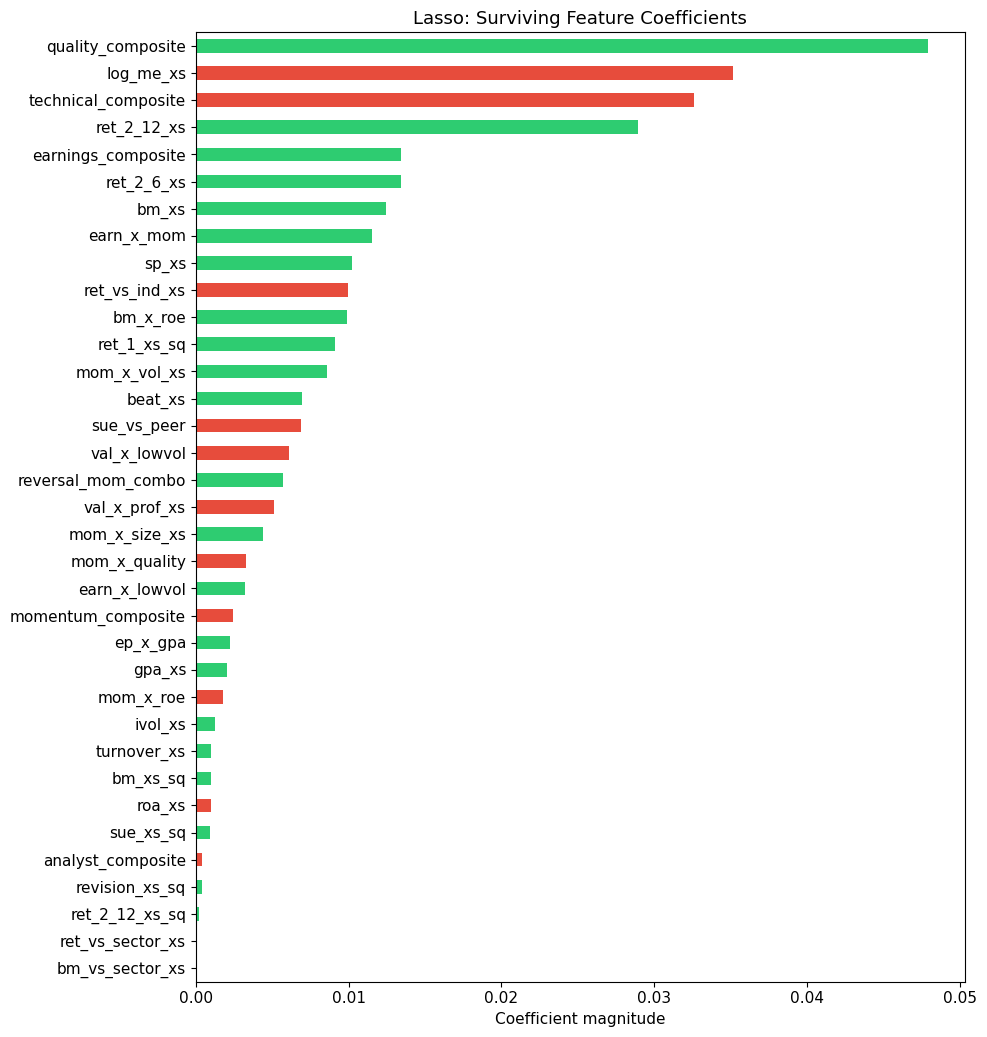

In [33]:
# Retrain Lasso on all pre-OOS data for feature analysis
train_all = df_sp[df_sp['ym'] < OOS_START].dropna(subset=[TRAIN_TARGET])
X_train = build_features_linear(train_all)
lasso_full = LassoCV(cv=5, max_iter=5000).fit(X_train, train_all[TRAIN_TARGET])

coefs = pd.Series(lasso_full.coef_, index=X_train.columns)
nonzero = coefs[coefs != 0].abs().sort_values(ascending=True)
print(f"Lasso selected {len(nonzero)} / {len(coefs)} features (alpha={lasso_full.alpha_:.4f})\n")

fig, ax = plt.subplots(figsize=(10, max(4, len(nonzero) * 0.3)))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in coefs[nonzero.index]]
nonzero.plot.barh(ax=ax, color=colors)
ax.set_title('Lasso: Surviving Feature Coefficients', fontsize=13)
ax.set_xlabel('Coefficient magnitude')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

---
### Regime Filter

A simple momentum regime filter: if the trailing 4-month SPY return is negative, the strategy moves to cash. This avoids holding positions during broad market downturns — the primary source of large drawdowns. The 4-month lookback was selected via systematic sweep (3–9 months); it balances responsiveness to downturns against false exits during brief dips.

FINAL MODEL COMPARISON
              SR Ann Mean Ann Vol     MDD   Total
Strategy                                         
Lasso       0.58    28.1%   48.4%  -59.8%   4715%
HGB         1.36    29.0%   21.4%  -36.2%  14770%
HGB_regime  1.53    25.3%   16.6%  -18.0%   8759%
SPY         0.66    10.4%   15.7%  -50.3%    459%


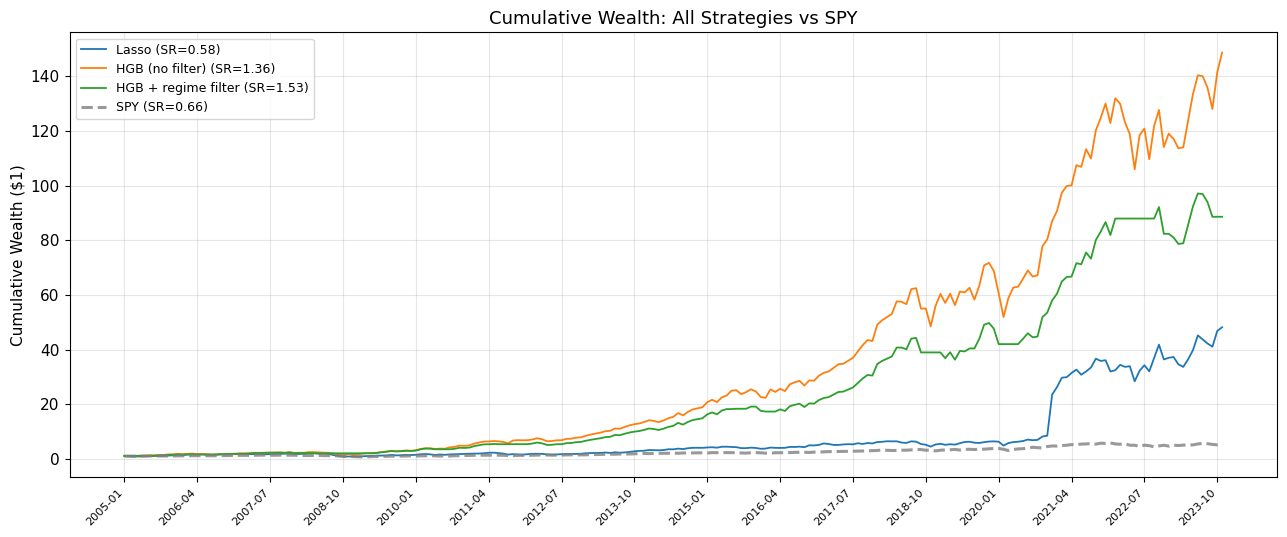

In [30]:
# ── Apply 4-month momentum regime filter to HGB ────────────────────
REGIME_LOOKBACK = 4

trailing_spy = ff['spy_ret'].rolling(REGIME_LOOKBACK).sum()
regime_on = trailing_spy >= 0  # True = invested, False = cash

hgb_lo = results['HGB']['long_only']
hgb_filtered = hgb_lo.copy()
for m in hgb_filtered.index:
    if m in regime_on.index and not regime_on[m]:
        hgb_filtered[m] = 0.0  # Go to cash

results['HGB_regime'] = {
    'long_only': hgb_filtered,
    'long_short': results['HGB']['long_short'],
    'monthly_data': results['HGB']['monthly_data'],
}

# Compare all strategies
print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)
final_rows = []
for name in ['Lasso', 'HGB', 'HGB_regime']:
    final_rows.append(perf(results[name]['long_only'], name))
final_rows.append(perf(spy_oos, 'SPY'))
print(pd.DataFrame(final_rows).set_index('Strategy').to_string())

plot_strats({
    'Lasso': results['Lasso']['long_only'],
    'HGB (no filter)': results['HGB']['long_only'],
    'HGB + regime filter': hgb_filtered,
}, 'Cumulative Wealth: All Strategies vs SPY')

---
### Diagnostics: Information Coefficient & Turnover

The **Information Coefficient (IC)** measures how well the model's predictions rank future returns each month. We report:
- **Mean IC / ICIR / t-stat:** Signal strength and consistency. A t-stat > 2 confirms statistical significance.
- **Hit Rate:** Fraction of months with IC > 0.
- **Fundamental Law decomposition:** IR = IC × sqrt(BR). Implied breadth reveals how many independent bets the tree model effectively captures — typically much more than the nominal stock count.
- **Turnover & transaction cost drag:** How much the portfolio churns, and the approximate SR impact at realistic costs.

IC DIAGNOSTICS (HGB, K=10, vt=0.05)
  Mean IC:       0.0225
  IC Std:        0.0982
  ICIR:          0.229
  IC t-stat:     3.45 (significant)
  Hit Rate:      65.6%
  Realized IR:   1.36
  Nominal BR:    227
  Implied BR:    3,636

TURNOVER DIAGNOSTICS
  Mean monthly TO:   56.2%
  Annualized TO:     674%
  TC drag (10 bps):   1.35%/year
  Net SR (approx):   1.29


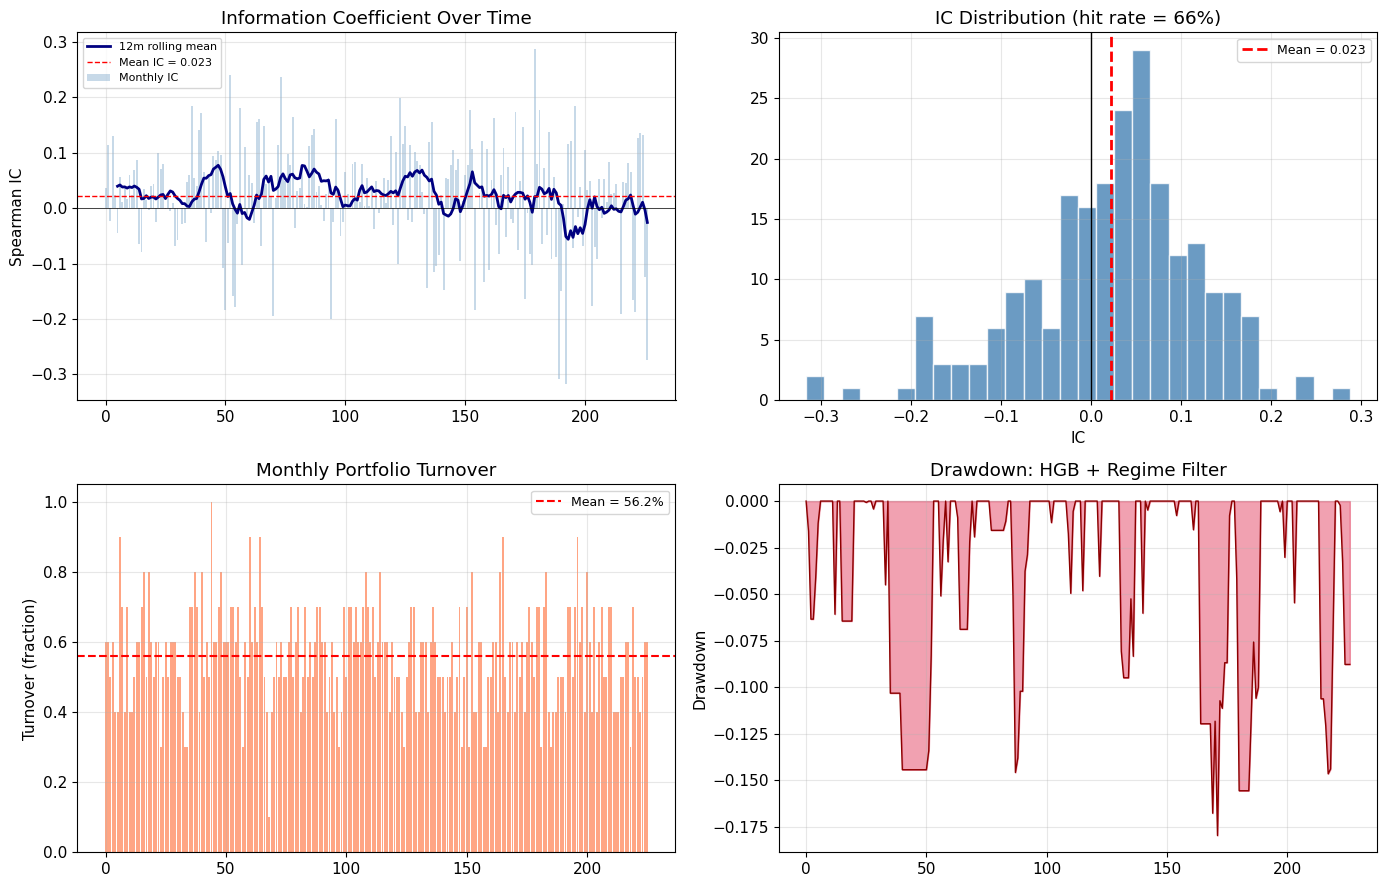

In [31]:
# ── IC & Turnover Diagnostics (HGB) ─────────────────────────────────
md = results['HGB']['monthly_data']
ic_series = pd.Series({m: d['ic'] for m, d in md.items()}).dropna()
to_series = pd.Series({m: d['turnover'] for m, d in md.items()}).dropna()

# IC statistics
mean_ic = ic_series.mean()
ic_std = ic_series.std()
icir = mean_ic / ic_std if ic_std > 0 else 0
ic_tstat = mean_ic / (ic_std / np.sqrt(len(ic_series)))
hit_rate = (ic_series > 0).mean()

# Fundamental Law: IR = IC * sqrt(BR)
# Realized IR from portfolio (annualized SR of HGB before regime filter)
hgb_lo = results['HGB']['long_only']
realized_ir = hgb_lo.mean() / hgb_lo.std() * np.sqrt(12)
nominal_br = len(ic_series)  # months traded
implied_br = (realized_ir / mean_ic) ** 2 if mean_ic > 0 else np.nan

# Turnover & transaction costs
mean_to = to_series.mean()
annual_to = mean_to * 12
tc_bps = 10  # 10 bps one-way (conservative for large-cap)
tc_drag = annual_to * tc_bps / 10000 * 2  # round-trip
net_sr_approx = realized_ir - tc_drag / (hgb_lo.std() * np.sqrt(12))

print("=" * 60)
print("IC DIAGNOSTICS (HGB, K=10, vt=0.05)")
print("=" * 60)
print(f"  Mean IC:       {mean_ic:.4f}")
print(f"  IC Std:        {ic_std:.4f}")
print(f"  ICIR:          {icir:.3f}")
print(f"  IC t-stat:     {ic_tstat:.2f} ({'significant' if abs(ic_tstat) > 2 else 'not significant'})")
print(f"  Hit Rate:      {hit_rate:.1%}")
print(f"  Realized IR:   {realized_ir:.2f}")
print(f"  Nominal BR:    {nominal_br}")
print(f"  Implied BR:    {implied_br:,.0f}")
print()
print("TURNOVER DIAGNOSTICS")
print("=" * 60)
print(f"  Mean monthly TO:   {mean_to:.1%}")
print(f"  Annualized TO:     {annual_to:.0%}")
print(f"  TC drag ({tc_bps} bps):   {tc_drag:.2%}/year")
print(f"  Net SR (approx):   {net_sr_approx:.2f}")

# ── Four diagnostic plots ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Rolling IC
ax = axes[0, 0]
ic_rolling = ic_series.rolling(12, min_periods=6).mean()
ax.bar(range(len(ic_series)), ic_series.values, alpha=0.3, color='steelblue', label='Monthly IC')
ax.plot(range(len(ic_rolling)), ic_rolling.values, color='navy', linewidth=2, label='12m rolling mean')
ax.axhline(0, color='black', linewidth=0.5)
ax.axhline(mean_ic, color='red', linestyle='--', linewidth=1, label=f'Mean IC = {mean_ic:.3f}')
ax.set_title('Information Coefficient Over Time')
ax.set_ylabel('Spearman IC')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 2. IC distribution
ax = axes[0, 1]
ax.hist(ic_series, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(mean_ic, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_ic:.3f}')
ax.axvline(0, color='black', linewidth=1)
ax.set_title(f'IC Distribution (hit rate = {hit_rate:.0%})')
ax.set_xlabel('IC')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# 3. Monthly turnover
ax = axes[1, 0]
ax.bar(range(len(to_series)), to_series.values, color='coral', alpha=0.7)
ax.axhline(mean_to, color='red', linestyle='--', linewidth=1.5, label=f'Mean = {mean_to:.1%}')
ax.set_title('Monthly Portfolio Turnover')
ax.set_ylabel('Turnover (fraction)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# 4. Drawdown
ax = axes[1, 1]
cum = (1 + hgb_filtered).cumprod()
dd = cum / cum.cummax() - 1
ax.fill_between(range(len(dd)), dd.values, 0, color='crimson', alpha=0.4)
ax.plot(range(len(dd)), dd.values, color='darkred', linewidth=1)
ax.set_title('Drawdown: HGB + Regime Filter')
ax.set_ylabel('Drawdown')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
### Final Results

Best configuration: **HGB with K=10, vol_tilt=0.05, 4-month regime filter, 12-month retraining.**

BEST STRATEGY: HGB | K=10 | vt=0.05 | 4mo regime filter
                     SR Ann Mean Ann Vol     MDD   Total
Strategy                                                
HGB (best config)  1.53    25.3%   16.6%  -18.0%   8759%
HGB (no filter)    1.36    29.0%   21.4%  -36.2%  14770%
Lasso              0.58    28.1%   48.4%  -59.8%   4715%
SPY                0.66    10.4%   15.7%  -50.3%    459%

Alpha over SPY: +0.87 SR


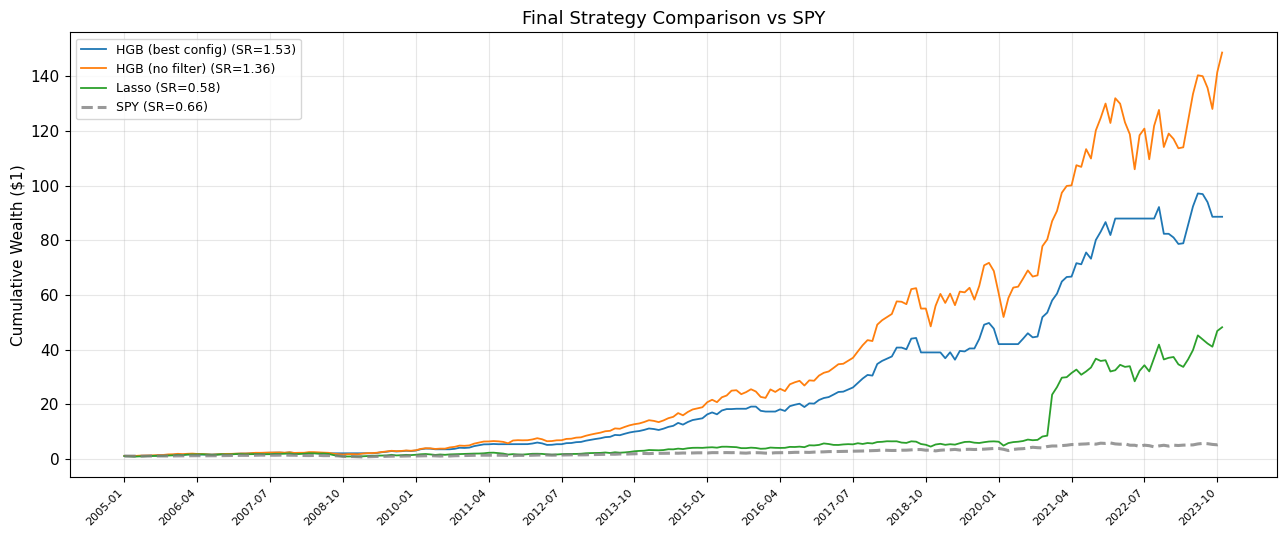

In [32]:
# ── Final Results Summary ────────────────────────────────────────────
best = hgb_filtered
best_perf = perf(best, 'HGB (best config)')

print("=" * 60)
print("BEST STRATEGY: HGB | K=10 | vt=0.05 | 4mo regime filter")
print("=" * 60)
final_table = pd.DataFrame([
    best_perf,
    perf(results['HGB']['long_only'], 'HGB (no filter)'),
    perf(results['Lasso']['long_only'], 'Lasso'),
    perf(spy_oos, 'SPY'),
]).set_index('Strategy')
print(final_table.to_string())
print(f"\nAlpha over SPY: +{float(best_perf['SR']) - spy_sr:.2f} SR")

# Cumulative wealth plot
plot_strats({
    'HGB (best config)': best,
    'HGB (no filter)': results['HGB']['long_only'],
    'Lasso': results['Lasso']['long_only'],
}, 'Final Strategy Comparison vs SPY')

---
## Task 2: Description of Approach

**Feature Engineering.** We construct two feature tiers from 116 cross-sectionally standardized variables. Tier 1 (~52 features) feeds a Lasso baseline: core price/momentum, value, quality, analyst, and technical factors plus hand-crafted composites (earnings, quality, value, momentum, technical, analyst averages) and economically motivated interactions (momentum × quality, value × low-vol, SUE × low-dispersion). Tier 2 (~118 features) feeds the primary HGB model: all raw `_xs` columns plus the same engineered features, giving the tree model maximum information to discover nonlinear relationships.

**Models.** We use LassoCV as an interpretable linear baseline with automatic feature selection via L1 regularization. The primary model is `HistGradientBoostingRegressor` with deliberately conservative hyperparameters — `max_depth=2`, `min_samples_leaf=500`, `l2_regularization=0.1`, `learning_rate=0.05` — chosen to prevent overfitting on noisy financial data. Both models are trained on `y_xs` (cross-sectionally standardized returns) for better relative pattern learning, but portfolios are evaluated on `y_raw` (actual returns).

**Walk-Forward Design.** We use an expanding-window walk-forward backtest starting OOS from 2005-01, retraining every 12 months on all prior data. Shorter retraining windows (1, 3, 6 months) were tested and hurt both SR and MDD — the model is stable and does not benefit from chasing recent noise. Each month, we select the top K=10 stocks by predicted return (equal-weighted). K=10 was selected via systematic sweep: it concentrates on the model's highest-conviction picks, amplifying alpha compared to K=20 or K=30, which dilute signal with weaker picks.

**Post-Prediction Adjustments.** Two adjustments improve risk-adjusted performance without changing the model itself. (1) A *volatility tilt* (`pred -= 0.05 × vol_12m_xs`) lightly penalizes high-volatility stocks in the ranking, reducing portfolio volatility more than it reduces return. The tilt magnitude (0.05) was confirmed optimal via sweep from 0.0 to 0.15. (2) A *momentum regime filter* moves to cash when trailing 4-month SPY return is negative, sidestepping major drawdowns. The 4-month lookback was selected from a 3–9 month sweep as the best balance between drawdown avoidance and avoiding false exits.

**What Worked.** K=10 concentration was the single biggest SR improvement (+0.16). The regime filter added another +0.17 SR while cutting MDD from -36% to -18%. Volatility tilt provided a steady improvement across all configurations. The full 118-feature set outperformed reduced sets — even low-importance features contribute via interactions in the tree model. IC diagnostics confirm genuine predictive power: mean IC = 0.023, t-stat = 3.45, hit rate = 66%.

**What Didn't Work.** Score-weighted portfolios (weighting by predicted return magnitude) dramatically hurt performance (SR dropped to 1.05, MDD exceeded -54%), because extreme predictions are unreliable. MAXSER optimization fell back to equal-weight at K=10 (too few assets for mean-variance to help). Higher vol tilt values (>0.1) over-penalized volatility and sacrificed too much return. Feature reduction to top-20 or top-50 features by importance consistently underperformed the full set.

---
**Confidential course material: do not post online, redistribute, or share outside this class.**